Iter 0: melhor fitness = 0.004219, barras usadas = 236
Iter 10: melhor fitness = 0.004255, barras usadas = 234
Iter 20: melhor fitness = 0.004274, barras usadas = 233
Iter 30: melhor fitness = 0.004310, barras usadas = 231
Iter 40: melhor fitness = 0.004255, barras usadas = 234
Iter 50: melhor fitness = 0.004167, barras usadas = 239
Iter 60: melhor fitness = 0.004274, barras usadas = 233
Iter 70: melhor fitness = 0.004184, barras usadas = 238
Iter 80: melhor fitness = 0.004367, barras usadas = 228
Iter 90: melhor fitness = 0.004202, barras usadas = 237
Iter 99: melhor fitness = 0.004184, barras usadas = 238

=== MELHOR SOLUÇÃO FINAL (GLOBAL) ===
Fitness: 0.0043859649122807015
Barras usadas: 227


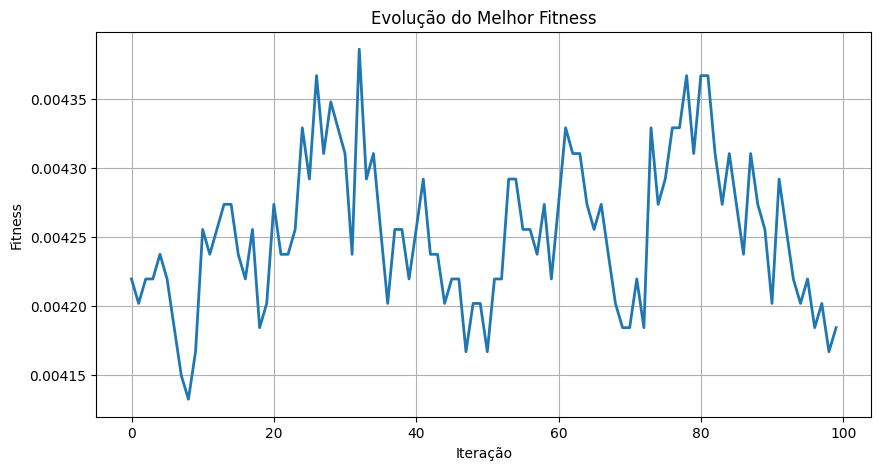

In [ ]:
import random
import copy
from dataclasses import dataclass, field
from typing import List
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)

@dataclass
class Individuo:
    genes: List[int] = field(default_factory=list)
    fitness: float = 0.0

class AlgoritmoGenetico:

    def __init__(self, tamPop, L, tamanhos, demandas, nBarras):
        self.tamPop = tamPop
        self.L = L
        self.tamanhos = tamanhos
        self.demandas = demandas
        self.nBarras = nBarras

        # cria lista expandida de itens
        self.items = []
        for i, d in enumerate(demandas):
            self.items += [i] * d


        self.numGenes = len(self.items)

        # Seleção
        self.pElite = 0.15
        self.pTorneio = 0.5 - self.pElite

        # Histórico para gráfico
        self.historico_fitness = []

    # ============================================================
    def execute(self, iter=10000):
        # inicializa com heurística gulosa (população válida)
        pop = self.inicializaPopulacaoA()
        popgulosa = max(self.inicializaPopulacaoB(), key=lambda x: x.fitness)

        # === MELHOR GLOBAL ===
        melhor_global = max(pop, key=lambda x: x.fitness)
        
        for it in range(iter):
            novaPop = []

            # Elite
            for _ in range(self.tamPop):

                if _ == 0:
                    pais = self.selecao(pop, False, popgulosa)
                else:
                    pais = self.selecao(pop, True)

                filho = self.cruzamento(pais)
                self.mutacao(filho)
                self.reparar(filho)
                self.fitness(filho)
                novaPop.append(filho)

            pop = novaPop

            # Melhor da geração
            melhor = max(pop, key=lambda x: x.fitness)
            self.historico_fitness.append(melhor.fitness)

            # === Atualiza melhor global ===
            if melhor.fitness > melhor_global.fitness:
                melhor_global = copy.deepcopy(melhor)

            # Log
            if (it % 10 == 0) or (it == iter - 1):
                print(f"Iter {it}: melhor fitness = {melhor.fitness:.6f}, barras usadas = {self.conta_barras_usadas(melhor)}")

        print("\n=== MELHOR SOLUÇÃO FINAL (GLOBAL) ===")
        print("Fitness:", melhor_global.fitness)
        barras_usadas = self.conta_barras_usadas(melhor_global)
        print("Barras usadas:", barras_usadas)
        # Gera gráficos
        self.plot_fitness()
        self.plot_cortes(melhor_global)

        print("\n=== OTIMIZAÇÃO DAS BARRAS ===")
        melhor_global = self.otimizar_barras(melhor_global, self.L)
        print("Fitness após otimização:", melhor_global.fitness)
        self.plot_cortes(melhor_global)

        return melhor_global



    def otimizar_barras(self, melhor_global, L):
        """
        Recebe um individuo com genes representando tamanhos de itens.
        Interpreta como barras empilhadas, otimiza movendo itens de baixo para cima
        até o limite L, removendo barras vazias.
        """

        genes = melhor_global.genes[:]  # copia
        # --- 1) AGRUPAR ITENS EM BARRAS DE TAMANHO <= L (de cima para baixo) ---
        barras = []
        barra_atual = []
        soma = 0

        for item in genes:
            if soma + item <= L:
                barra_atual.append(item)
                soma += item
            else:
                barras.append(barra_atual)
                barra_atual = [item]
                soma = item

        if barra_atual:
            barras.append(barra_atual)

        # Agora barras[0] = primeira barra, barras[-1] = última
        mudou = True

        # --- 2) LOOP DE OTIMIZAÇÃO (compactar de baixo p/ cima) ---
        while mudou:
            mudou = False

            for i in range(len(barras) - 1, 0, -1):  # da última barra até a segunda
                barra_inf = barras[i]
                barra_sup = barras[i - 1]

                soma_sup = sum(barra_sup)

                # tenta mover itens da barra inferior para a superior
                itens_para_remover = []

                for item in barra_inf:
                    if soma_sup + item <= L:
                        barra_sup.append(item)
                        soma_sup += item
                        itens_para_remover.append(item)
                        mudou = True

                # remove itens movidos
                for item in itens_para_remover:
                    barra_inf.remove(item)

                # se barra inferior esvaziou → remove
                if len(barra_inf) == 0:
                    barras.pop(i)

        # --- 3) Reconstruir lista de genes ---
        novos_genes = []
        for barra in barras:
            novos_genes.extend(barra)

        # --- 4) Retorna novo indivíduo ---
        return Individuo(genes=novos_genes, fitness=melhor_global.fitness)



    # ============================================================
    def plot_fitness(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.historico_fitness, linewidth=2)
        plt.title("Evolução do Melhor Fitness")
        plt.xlabel("Iteração")
        plt.ylabel("Fitness")
        plt.grid(True)
        plt.show()

    # ============================================================
    def plot_cortes(self, ind: Individuo):
        # Cria estrutura vazia de barras
        barras = [[] for _ in range(self.nBarras)]

        # Coloca cada item na sua barra
        for gene, item in zip(ind.genes, self.items):
            barras[gene].append(self.tamanhos[item])

        # Remove barras vazias
        barras = [b for b in barras if len(b) > 0]

        # === ORDENA TODOS OS CORTES DENTRO DE CADA BARRA ===
        for b in barras:
            b.sort(reverse=True)  # maior -> menor

        # === ORDENA AS BARRAS POR CONSUMO TOTAL (maior primeiro) ===
        # barras é uma lista de listas de cortes: [ [10,5,7], [3,1], ... ]
        # precisamos transformar em: [ [cortes, total], ... ]

        barras = [[b, sum(b)] for b in barras]       # vira lista mutável
        barras.sort(key=lambda x: x[1], reverse=True)

        
        # pega a última barra (com menor consumo)
        ultima_barra = barras[-1]
        diferenca = self.L - ultima_barra[1]


        # encontra indices de barras com espaço suficiente
        indices_barras_com_espaco = [
            i for i, b in enumerate(barras)
            if b[1] <= diferenca and i != len(barras) - 1
        ]

        if indices_barras_com_espaco:
            idx = indices_barras_com_espaco[0]

            # === mover cortes ===
            barras[idx][0].extend(ultima_barra[0])    # adiciona cortes
            barras[idx][1] += ultima_barra[1]         # soma consumo

            # === remove a última ===
            barras.pop()


        # ==== PLOT ====
        n = len(barras)
        plt.figure(figsize=(10, max(6, n * 0.25)))

        for idx, barra in enumerate(barras):
            x = 0
            for tamanho in barra:
                plt.barh(idx, tamanho, left=x, edgecolor='black')
                plt.text(x + tamanho / 2, idx, f"{tamanho}",
                        ha='center', va='center', fontsize=8)
                x += tamanho

            # linha limite da barra
            plt.plot([self.L, self.L], [idx - 0.4, idx + 0.4], 'r--')

        plt.title("Gráfico dos cortes por barra (ordenado)")
        plt.xlabel("Comprimento")
        plt.ylabel("Barra")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()


    def gera_individuo_guloso(self):
        # cria vetor genes vazio
        genes = [-1] * self.numGenes

        # itens como pares (tamanho, idx_no_vetor_original)
        itens = [(self.tamanhos[self.items[i]], i) for i in range(self.numGenes)]

        # ordena por tamanho descrescente
        itens.sort(reverse=True)

        consumo = [0] * self.nBarras

        for tam, pos in itens:
            # tenta colocar nas barras
            colocado = False
            for b in range(self.nBarras):
                if consumo[b] + tam <= self.L:
                    consumo[b] += tam
                    genes[pos] = b
                    colocado = True
                    break

            # se não colocou (teoricamente raro)
            if not colocado:
                # joga na primeira barra vazia
                for b in range(self.nBarras):
                    if consumo[b] == 0:
                        consumo[b] += tam
                        genes[pos] = b
                        break

        return Individuo(genes=genes)

    def inicializaPopulacaoA(self):
        pop = []
        for _ in range(self.tamPop):
            ind = Individuo()
            ind.genes = [random.randint(0, self.nBarras - 1) for _ in range(self.numGenes)]
            self.reparar(ind)
            self.fitness(ind)
            pop.append(ind)
        return pop
    
    # ============================================================
    def inicializaPopulacaoB(self):
        pop = []

        # --- Criar população inteira usando heurística gulosa simples ---
        for _ in range(self.tamPop):
            pop.append(self.gera_individuo_guloso())
        
        # Avaliar fitness
        for ind in pop:
            self.fitness(ind)

        return pop


    # ============================================================
    def fitness(self, ind: Individuo):
        consumo = [0] * self.nBarras

        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        for c in consumo:
            if c > self.L:
                ind.fitness = 0.0
                return 0.0

        usadas = sum(1 for c in consumo if c > 0)
        ind.fitness = 1.0 / (1.0 + usadas)
        return ind.fitness

    # ============================================================
    def reparar(self, ind: Individuo):
        """Repara indivíduo movendo itens de barras sobrecarregadas para barras com espaço."""
        consumo = [0] * self.nBarras
        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        # itera os índices dos genes e garante que nenhum consumo > L ao final
        for i, (g, item_idx) in enumerate(zip(ind.genes, self.items)):
            tam = self.tamanhos[item_idx]
            if consumo[g] > self.L:
                # retira da barra atual
                consumo[g] -= tam
                colocado = False
                # procura uma barra que comporte
                for b in range(self.nBarras):
                    if consumo[b] + tam <= self.L:
                        ind.genes[i] = b
                        consumo[b] += tam
                        colocado = True
                        break
                if not colocado:
                    # se não encontrou (muito improvável com nBarras grande), coloca na barra com menor uso
                    b = min(range(self.nBarras), key=lambda x: consumo[x])
                    ind.genes[i] = b
                    consumo[b] += tam
        return ind

    # ============================================================
    def conta_barras_usadas(self, ind):
        consumo = [0] * self.nBarras
        for g, it in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[it]
        return sum(1 for c in consumo if c > 0)


    # ============================================================
    def selecao(self, pop, estado_elite=True, popgulosa=None):
        if estado_elite == True:
            popOrdenada = sorted(pop, key=lambda x: x.fitness, reverse=True)
            numElite = max(1, int(self.pElite * self.tamPop))
            elite = popOrdenada[:numElite]
        else:
            elite = popgulosa, popgulosa

        torneioTam = 2
        torneio = random.sample(pop, torneioTam)
        vencedor = max(torneio, key=lambda x: x.fitness)

        return random.choice(elite), vencedor


    # ============================================================
    def cruzamento(self, pais):
        p = random.randint(1, self.numGenes - 1)
        filho = Individuo()
        filho.genes = pais[0].genes[:p] + pais[1].genes[p:]
        return filho


    # ============================================================
    def mutacao(self, ind, taxa=0.05):
        for i in range(len(ind.genes)):
            if random.random() < taxa:
                ind.genes[i] = random.randint(0, self.nBarras - 1)





# ============================================================
# EXEMPLO DE EXECUÇÃO (cole e rode localmente)
# L = 60
# tamanhos = [11, 3, 20, 7, 25, 14, 1, 19, 6, 24, 9, 18, 4, 16, 22, 8, 12, 5, 27, 10, 21, 2, 26, 13, 23, 15, 17, 28, 29, 30]
# demandas = [10, 3, 2, 7, 5, 4, 100, 10, 6, 2, 9, 1, 4, 3, 2, 8, 5, 5, 2, 10, 2, 2, 26, 13, 3, 5, 7, 8, 9, 3]

L = 90
tamanhos = [
    3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
    23, 25, 27, 29, 31, 33, 35, 37, 39, 41,
    43, 45, 47, 49, 51, 53, 55, 57, 59, 61,
    63, 65, 67, 69, 71, 73, 75, 77, 79, 81
]

demandas = [
     2, 15, 12, 8, 5, 3, 10, 5, 3, 2,
     3, 18, 14, 10, 6, 4, 15, 8, 5, 3,
     2, 16, 13, 9, 55, 35, 2, 1, 5, 3,
     2, 17, 15, 11, 7, 4, 18, 9, 6, 1
]

# juntando tamanhos e demandas
pares = list(zip(tamanhos, demandas))

# ordenando pelo primeiro elemento (tamanho)
pares_ordenados = sorted(pares, key=lambda x: x[0])

# separando novamente
tamanhos_ordenados, demandas_ordenadas = zip(*pares_ordenados)

tamanhos_ordenados = list(tamanhos_ordenados)
demandas_ordenadas = list(demandas_ordenadas)
nBarras = 300

ga = AlgoritmoGenetico(
    tamPop=10,
    L=L,
    tamanhos=tamanhos_ordenados,
    demandas=demandas_ordenadas,
    nBarras=nBarras
)

melhor = ga.execute(iter=100)


In [ ]:
a= Individuo(genes=[11, 10, 44, 44, 44, 43, 43, 43, 42, 42, 42, 33, 33, 33, 32, 32, 32, 31, 31, 30, 30, 29, 29, 28, 28, 27, 27, 26, 26, 15, 14, 13, 12, 11, 10, 6, 0, 5, 4, 3, 2, 1, 9, 8, 7, 25, 24, 23, 22, 21, 20, 1, 18, 17, 16, 41, 37, 36, 35, 34, 40, 39, 38, 46, 45, 58, 57, 56, 150, 87, 86, 85, 84, 83, 82, 81, 80, 79, 78, 77, 76, 1, 74, 73, 1, 71, 149, 148, 147, 146, 145, 144, 143, 268, 2, 135, 134, 133, 89, 88, 132, 131, 130, 2, 128, 127, 126, 92, 91, 3, 125, 97, 96, 95, 94, 93, 124, 3, 122, 98, 121, 120, 119, 118, 4, 116, 115, 114, 113, 112, 111, 110, 109, 100, 99, 108, 107, 106, 105, 104, 103, 4, 101, 140, 139, 138, 137, 136, 193, 192, 191, 201, 200, 220, 220, 5, 263, 218, 218, 217, 217, 216, 216, 215, 215, 214, 214, 213, 213, 212, 211, 210, 7, 208, 207, 206, 205, 8, 219, 202, 201, 200, 199, 198, 24, 196, 195, 194, 193, 192, 191, 190, 25, 43, 187, 186, 101, 184, 183, 182, 105, 180, 179, 178, 109, 176, 175, 174, 173, 172, 171, 170, 169, 168, 167, 166, 165, 164, 163, 162, 161, 160, 159, 158, 157, 156, 155, 154, 153, 152, 151, 150, 149, 148, 147, 146, 145, 144, 143, 142, 141, 140, 139, 138, 137, 136, 135, 134, 110, 132, 131, 130, 111, 128, 127, 126, 125, 124, 121, 122, 133, 120, 119, 118, 203, 116, 115, 114, 113, 112, 6, 129, 209, 108, 107, 106, 221, 104, 103, 102, 222, 100, 99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 223, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 0, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 275, 188, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 123, 204, 59, 189, 181, 117, 177, 197, 185], fitness=0.0043859649122807015)

barrasUsadas = 227
#loop principal:
piorBarra = 

max(a.genes)


275